<a href="https://colab.research.google.com/github/anujsanap25-nxtwave/Data_science_lab_SE_76/blob/main/pr6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [2]:
import pandas as pd
import numpy as np

In [31]:
df = pd.read_csv("Titanic-Dataset.csv")

In [32]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [33]:
#To load and clean the Titanic dataset.

df.count()

,0
PassengerId,891
Survived,891
Pclass,891
Name,891
Sex,891
Age,714
SibSp,891
Parch,891
Ticket,891
Fare,891


In [34]:
# Fill missing 'Embarked' values with the most frequent value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Age'] = df['Age'].fillna(df['Age'].mean())

df.drop('Cabin', axis=1, inplace=True)

# Display the count of non-null values after cleaning
df.count()

,0
PassengerId,891
Survived,891
Pclass,891
Name,891
Sex,891
Age,891
SibSp,891
Parch,891
Ticket,891
Fare,891


In [35]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [36]:
df['Sex_male'] = df['Sex'].apply(lambda x: 1 if x == 'male' else 0)
male_count = df['Sex_male'].sum()
print(f"Number of males: {male_count}")

Number of males: 577


In [37]:
male_died_count = df[(df['Sex_male'] == 1) & (df['Survived'] == 0)].shape[0]
print(f"Number of males who died: {male_died_count}")

Number of males who died: 468


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style('whitegrid')

# 1. Survival Rate by Sex
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex_male', hue='Survived', data=df)
plt.title('Survival Count by Gender (0=Female, 1=Male)')
plt.xlabel('Gender (blue =Male, orange=Female)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()
print()
# 2. Survival Rate by Pclass
plt.figure(figsize=(7, 5))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

In [ ]:
print("Interactive DataFrame Operations:")
print("1. Display Head")
print("2. Display Tail")
print("3. Get Info")
print("4. Check Nulls")
print("5. Descriptive Statistics")
print("6. Unique Values (specify column)")
print("7. Value Counts (specify column)")
print("8. Filter by Survival (show survivors)")
print("9. Calculate Mean Age by Pclass")
print("10. Add 'FamilySize' Column")
print("11. Drop a Column (specify column)")
print("Type 'exit' to quit.")

operation_input = input("\nEnter operation number or type 'exit': ")

match operation_input:
    case '1':
        display(df.head())

    case '2':
        display(df.tail())

    case '3':
        df.info()

    case '4':
        display(df.isnull().sum())

    case '5':
        display(df.describe())

    case '6':
        column = input("Enter column name for unique values: ")
        if column in df.columns:
            display(df[column].unique())
        else:
            print(f"Column '{column}' not found.")

    case '7':
        display(df.columns)
        column = input("Enter column name for value counts: ")
        if column in df.columns:
            display(df[column].value_counts())
        else:
            print(f"Column '{column}' not found.")

    case '8':
        survivors = df[df['Survived'] == 1]
        print("Passengers who survived:")
        display(survivors.head())

    case '9':
        if 'Age' in df.columns and 'Pclass' in df.columns:
            mean_age_by_pclass = df.groupby('Pclass')['Age'].mean()
            print("Mean Age by Pclass:")
            display(mean_age_by_pclass)
        else:
            print("Required columns ('Age' or 'Pclass') not found.")

    case '10':
        if 'SibSp' in df.columns and 'Parch' in df.columns:
            df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
            print("'FamilySize' column added. Displaying head with new column:")
            display(df.head(100))
        else:
            print("Required columns ('SibSp' or 'Parch') not found.")

    case '11':
        column_to_drop = input("Enter column name to drop: ")
        if column_to_drop in df.columns:
            df.drop(column_to_drop, axis=1, inplace=True)
            print(f"Column '{column_to_drop}' dropped. DataFrame head after dropping:")
            display(df.head())

        else:
            print(f"Column '{column_to_drop}' not found.")

    case 'exit':
        print("Exiting interactive operations.")

    case _:
        print("Invalid operation. Please choose a number from 1-11 or type 'exit'.")

In [ ]:
df['FamilySize'].unique()

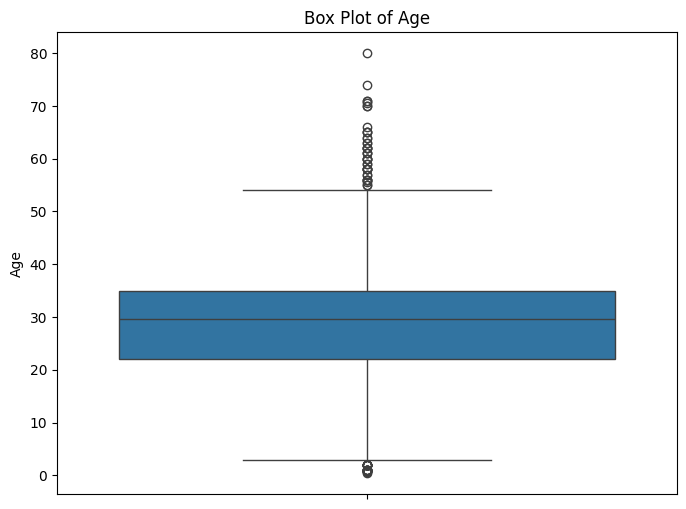

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

In [24]:
df['Age'].max()

80.0

In [40]:
df = df[df['Age'] != 80]

# Or, to drop specific rows by index:
# rows_to_drop = df[df['Age'] == 80].index
# df.drop(rows_to_drop, inplace=True)

print("Rows with Age 80 have been removed, if any existed.")
print(f"Max age after potential removal: {df['Age'].max()}")

Rows with Age 80 have been removed, if any existed.
Max age after potential removal: 74.0


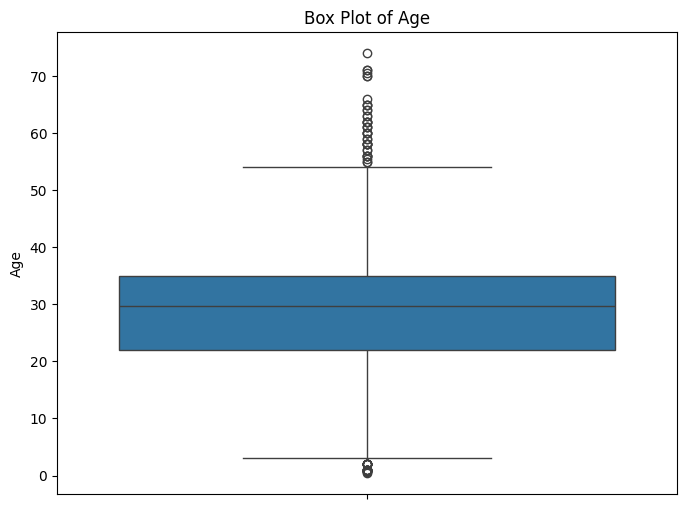

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

In [42]:
from scipy.stats import zscore

# Calculate Z-scores for the 'Age' column
df['Age_Zscore'] = zscore(df['Age'])

# Define a threshold for outliers (e.g., |Z-score| > 3)
outlier_threshold = 3

# Identify outliers
age_outliers = df[(df['Age_Zscore'] > outlier_threshold) | (df['Age_Zscore'] < -outlier_threshold)]

print(f"Outliers in 'Age' based on Z-score > {outlier_threshold} or < -{outlier_threshold}:")
display(age_outliers[['Age', 'Age_Zscore']])

Outliers in 'Age' based on Z-score > 3 or < -3:


,Age,Age_Zscore
96,71.0,3.207964
116,70.5,3.169181
493,71.0,3.207964
672,70.0,3.130397
745,70.0,3.130397
851,74.0,3.440665
